In [40]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

## Task 1: Dataset Exploration


In [3]:
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)


In [5]:
df['target'] = iris.target

1. How many samples and features are present in the dataset?

In [6]:
print("Number of samples:", iris.data.shape[0])
print("Number of features:", iris.data.shape[1])

Number of samples: 150
Number of features: 4


2. List the feature names and target classes.


In [7]:
print("Feature Names:")
print(iris.feature_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
print("Target Classes:")
print(iris.target_names)

Target Classes:
['setosa' 'versicolor' 'virginica']


3. Display the first five records.

In [9]:
print("First Five Records:")
print(df.head())

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


4. Display the class distribution.

In [10]:
print(df['target'].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


## Task 2: Data Preparation

In [12]:
X = iris.data
y = iris.target

1. Split the dataset into training (80%) and testing (20%) sets using random_state = 42.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [16]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


The dataset is split into training and testing sets to evaluate how well a machine learning model performs on new, unseen data.

- Training Set (80%): Used to train the model so it can learn patterns and relationships from the data.
- Testing Set (20%): Used to evaluate the trained model's performance on data it has not seen before.

## Task 3: Building a Decision Tree Classifier

1. Train a Decision Tree classifier using the default parameters.

In [18]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

2. Predict the class labels for the test dataset.

In [19]:
y_pred = model.predict(X_test)

3. Evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report


In [20]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names = iris.target_names))

Accuracy Score:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree

1. Visualize the trained Decision Tree using plot_tree().

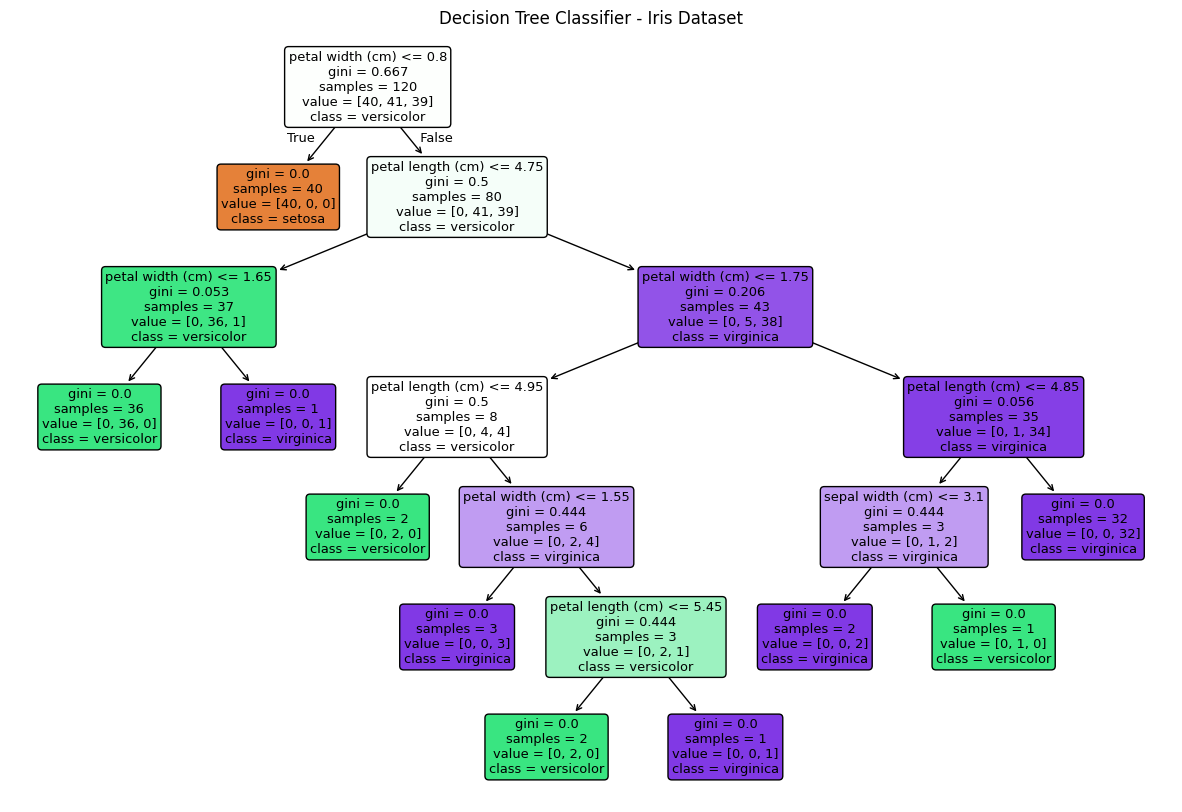

In [25]:
plt.figure(figsize = (15, 10))
plot_tree(model, feature_names = iris.feature_names, class_names = iris.target_names, filled = True, rounded = True)
plt.title("Decision Tree Classifier - Iris Dataset")
plt.show()

2. From the visualization, identify:
- Root node
- Internal nodes
- Leaf nodes
- Maximum depth of the tree


Root Node:

petal width (cm) <= 0.8

Internal Nodes:

- petal width (cm) <= 0.8 (Root Node)
- petal length (cm) <= 4.75
- petal width (cm) <= 1.65
- petal width (cm) <= 1.75
- petal length (cm) <= 4.95
- petal width (cm) <= 1.55
- petal length (cm) <= 4.85
- petal length (cm) <= 5.45
- sepal width (cm) <= 3.1

Leaf Nodes:

- Setosa
- Versicolor
- Virginica

Maximum Depth of the Tree: 

The longest path from the root node to a leaf node contains 5 levels of splits.

Maximum Depth = 5

3. Which feature is selected for the first split? Explain why you think this feature was chosen.

The first feature selected is:

petal width (cm) <= 0.8

The Decision Tree algorithm selects the feature that best separates the classes by minimizing Gini Impurity (the default criterion in DecisionTreeClassifier).

## Task 5: Comparing Gini Index and Entropy

Train two Decision Tree models using the following criteria:
- criterion='gini'
- criterion='entropy'


In [26]:
gini_model = DecisionTreeClassifier(criterion = 'gini', random_state = 42)
gini_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [27]:
entropy_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
entropy_model.fit(X_train, y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [28]:
gini_pred = gini_model.predict(X_test)
entropy_pred = entropy_model.predict(X_test)

Compare the models based on:
- Accuracy
- Tree depth
- Number of leaf nodes
- Root feature selected
- Which criterion produces a simpler tree?


In [29]:
gini_accuracy = accuracy_score(y_test, gini_pred)
entropy_accuracy = accuracy_score(y_test, entropy_pred)

# Display comparison
print("Gini Accuracy:", gini_accuracy)
print("Entropy Accuracy:", entropy_accuracy)

print("Gini Tree Depth:", gini_model.get_depth())
print("Entropy Tree Depth:", entropy_model.get_depth())

print("Gini Leaf Nodes:", gini_model.get_n_leaves())
print("Entropy Leaf Nodes:", entropy_model.get_n_leaves())

print("Gini Root Feature:",
      iris.feature_names[gini_model.tree_.feature[0]])

print("Entropy Root Feature:",
      iris.feature_names[entropy_model.tree_.feature[0]])

Gini Accuracy: 1.0
Entropy Accuracy: 1.0
Gini Tree Depth: 6
Entropy Tree Depth: 6
Gini Leaf Nodes: 10
Entropy Leaf Nodes: 10
Gini Root Feature: petal length (cm)
Entropy Root Feature: petal length (cm)


## Task 6: Effect of Maximum Tree Depth

Train Decision Tree models using the following values of max_depth:
- 1
- 2
- 3
- 4
- None


In [31]:
depths = [1, 2, 3, 4, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append([depth, round(train_acc, 3), round(test_acc, 3), model.get_depth()])


In [32]:
df = pd.DataFrame(results, columns = ["Max Depth", "Training Accuracy", "Testing Accuracy", "Tree Depth"])
print(df)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth
0        1.0              0.675             0.633           1
1        2.0              0.950             0.967           2
2        3.0              0.958             1.000           3
3        4.0              0.975             1.000           4
4        NaN              1.000             1.000           6


| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|-----------|------------------:|-----------------:|-----------:|-------------|
| 1 | 0.675 | 0.633 | 1 | Very shallow tree. Low training and testing accuracy, indicating **underfitting**. |
| 2 | 0.950 | 0.967 | 2 | Good performance with a simple tree. Generalizes well while maintaining low complexity. |
| 3 | 0.958 | 1.000 | 3 | Excellent balance between complexity and performance. Achieves perfect testing accuracy with a relatively simple tree. |
| 4 | 0.975 | 1.000 | 4 | High training and testing accuracy. More complex than depth 3 but still generalizes well. |
| None | 1.000 | 1.000 | 6 | Fully grown tree with the highest complexity. Fits the training data perfectly and may overfit on larger or noisier datasets. |

1. Which model is underfitting?

Max Depth = 1

Justification:

It has the lowest training accuracy (67.5%) and lowest testing accuracy (63.3%).
The tree is too shallow to capture the patterns in the dataset, resulting in poor performance on both training and testing data.

2. Which model gives the best generalization?

Max Depth = 3

Justification:

It achieves 100% testing accuracy while maintaining a relatively simple tree (depth = 3).
Compared to deeper trees, it provides an excellent balance between model complexity and predictive performance, making it the best choice for generalization.

3. Which model is likely to overfit? Justify your answer.

Max Depth = None

Justification:

- This model grows the tree without any depth restriction, resulting in the deepest tree (depth = 6).
- It achieves 100% training accuracy, meaning it has perfectly fit the training data.
- Although it also scores 100% testing accuracy on the Iris dataset (which is small and relatively simple), such a fully grown tree is more likely to memorize the training data and overfit when applied to larger, more complex, or noisier datasets.
- Therefore, Max Depth = None has the highest risk of overfitting due to its increased complexity.

## Task 7: Effect of min_samples_split

Train Decision Tree models using:
- 2
- 5
- 10
- 20
Complete the table below.


In [33]:
split_values = [2, 5, 10, 20]

results = []

for split in split_values:
    model = DecisionTreeClassifier(min_samples_split = split, random_state = 42)

    model.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, model.predict(X_test))

    results.append([split, round(accuracy, 3), model.get_depth(), model.get_n_leaves()])

In [34]:
df = pd.DataFrame(results, columns = ["min_samples_split", "Accuracy", "Tree Depth", "Number of Leaf Nodes"]) 

print(df)

   min_samples_split  Accuracy  Tree Depth  Number of Leaf Nodes
0                  2       1.0           6                    10
1                  5       1.0           5                     8
2                 10       1.0           4                     6
3                 20       1.0           4                     6


| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|------------------:|---------:|-----------:|---------------------:|-------------|
| 2 | 1.000 | 6 | 10 | Fully grown tree with the highest complexity. Achieves perfect accuracy but has the maximum number of splits and leaf nodes. |
| 5 | 1.000 | 5 | 8 | Slightly simpler tree with fewer splits and leaf nodes while maintaining perfect accuracy. |
| 10 | 1.000 | 4 | 6 | Simpler tree with reduced depth and fewer leaf nodes. Maintains perfect accuracy, indicating good generalization. |
| 20 | 1.000 | 4 | 6 | Same depth and number of leaf nodes as `min_samples_split = 10`. The tree remains simple while still achieving perfect accuracy. |

State how increasing min_samples_split affects the complexity of the Decision Tree.

Increasing the value of min_samples_split generally reduces the complexity of the Decision Tree because a node must contain more samples before it can be split.

From the results:

- When min_samples_split increases from 2 to 5, the tree depth decreases from 6 to 5, and the number of leaf nodes decreases from 10 to 8.
- Increasing it further to 10 reduces the tree depth to 4 and the number of leaf nodes to 6.
- Increasing it from 10 to 20 does not change the tree structure because no additional splits satisfied the minimum sample requirement.

Although the tree becomes simpler as min_samples_split increases, the testing accuracy remains 100% for all four values. This indicates that the Iris dataset is simple enough that a less complex tree can classify all test samples correctly. In general, increasing min_samples_split helps reduce overfitting by preventing unnecessary splits, but setting it too high on more complex datasets may lead to underfitting and reduced accuracy.

## Task 8: Effect of min_samples_leaf

Train Decision Tree models using:
- 1
- 2
- 5
- 10

In [35]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf = leaf, random_state = 42)

    model.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, model.predict(X_test))

    results.append([leaf, round(accuracy, 3), model.get_depth(), model.get_n_leaves()])

In [36]:
df = pd.DataFrame(results, columns = ["min_samples_leaf", "Accuracy", "Tree Depth", "Number of Leaf Nodes"])

print(df)

   min_samples_leaf  Accuracy  Tree Depth  Number of Leaf Nodes
0                 1     1.000           6                    10
1                 2     1.000           5                     8
2                 5     1.000           4                     6
3                10     0.967           4                     6


| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|-----------------:|---------:|-----------:|---------------------:|-------------|
| 1 | 1.000 | 6 | 10 | Fully grown tree with the highest complexity. Achieves perfect accuracy but has the maximum depth and number of leaf nodes. |
| 2 | 1.000 | 5 | 8 | Slightly simpler tree with fewer leaf nodes while maintaining perfect accuracy. |
| 5 | 1.000 | 4 | 6 | Simpler tree with reduced depth and fewer leaf nodes. Maintains perfect accuracy and provides good generalization. |
| 10 | 0.967 | 4 | 6 | Increasing the minimum samples per leaf simplifies the tree, but the higher constraint causes a slight drop in accuracy. |

## Task 9: Hyperparameter Tuning

Perform hyperparameter tuning using GridSearchCV with the following parameters:
- criterion: gini, entropy
- max_depth: 2, 3, 4, None
- min_samples_split: 2, 5, 10
- min_samples_leaf: 1, 2, 4


In [37]:
default_model = DecisionTreeClassifier(random_state = 42)
default_model.fit(X_train, y_train)
default_accuracy = accuracy_score(y_test, default_model.predict(X_test))

In [38]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [41]:
grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state = 42), param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)

In [42]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

In [43]:
best_model = grid_search.best_estimator_

In [44]:
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))

In [45]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

print("\nOptimized Model Test Accuracy:")
print(test_accuracy)

print("\nDefault Decision Tree Test Accuracy:")
print(default_accuracy)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score:
0.9583333333333334

Optimized Model Test Accuracy:
1.0

Default Decision Tree Test Accuracy:
1.0


1. Best hyperparameter combination.


Criterion          : entropy

Max Depth          : None

Min Samples Split  : 2

Min Samples Leaf   : 4

2. Best cross validation score.


0.9583 (95.83%)

3. Test Accuracy of the Optimized Model.

1.000 (100%)

4. Compare the optimized model with the default Decision Tree model.


1.000 (100%)

| Model | Criterion | Max Depth | Min Samples Split | Min Samples Leaf | Cross Validation Score | Test Accuracy |
|-------|-----------|-----------|-------------------|------------------|-----------------------:|--------------:|
| Default Decision Tree | gini (default) | None | 2 | 1 | - | 1.000 |
| Optimized Decision Tree | entropy | None | 2 | 4 | 0.9583 | 1.000 |